# fio-cmp: DAOS (dfs) vs NVMe-oF (libaio)

Sequential read comparison across block sizes 4K / 1M / 4M.
Single job, iodepth=32. Metrics: bandwidth, IOPS, latency percentiles, CPU usage.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

RESULTS_DIR = Path(".")

BS_ORDER = ["4k", "1m", "4m"]
COLORS   = {"daos": "#1f77b4", "nvmeof": "#ff7f0e"}
LABELS   = {"daos": "DAOS (dfs)", "nvmeof": "NVMe-oF (libaio)"}


In [2]:
def parse_file(fpath):
    name = Path(fpath).stem
    backend = "daos" if name.startswith("daos") else "nvmeof"
    bs = name.split("_bs")[1].split("_")[0]

    with open(fpath) as f:
        d = json.load(f)

    j = d["jobs"][0]
    r = j["read"]
    pct = r["clat_ns"]["percentile"]

    return dict(
        backend     = backend,
        block_size  = bs,
        bw_GiBs      = r["bw_bytes"] / (1024**3),
        iops        = r["iops"],
        lat_mean_ms = r["lat_ns"]["mean"]  / 1e6,
        lat_max_ms  = r["lat_ns"]["max"]  / 1e6,
        clat_p50_ms  = pct["50.000000"]     / 1e6,
        clat_p90_ms  = pct["90.000000"]     / 1e6,
        clat_p99_99_ms = pct["99.990000"]     / 1e6,
        slat_us     = r["slat_ns"]["mean"] / 1e3,
        clat_ms     = r["clat_ns"]["mean"] / 1e6,
        usr_cpu     = j["usr_cpu"],
        sys_cpu     = j["sys_cpu"],
    )

rows = [parse_file(f) for f in sorted(RESULTS_DIR.glob("*.json"))]
df = pd.DataFrame(rows)
df["block_size"] = pd.Categorical(df["block_size"], categories=BS_ORDER, ordered=True)
df = df.sort_values(["block_size", "backend"]).reset_index(drop=True)
df


,backend,block_size,bw_GiBs,iops,lat_mean_ms,lat_max_ms,clat_p50_ms,clat_p90_ms,clat_p99_99_ms,slat_us,clat_ms,usr_cpu,sys_cpu
0,nvmeof,4m,0.800028,204.807127,139.139240,161.784226,133.693440,145.752064,158.334976,4356.141029,134.783098,0.070036,70.879090
1,nvmeof,4m,0.838799,214.732576,131.747876,150.823367,127.401984,132.644864,145.752064,4124.973637,127.622903,0.044058,70.125712
2,nvmeof,4m,0.851606,218.011033,129.712005,143.743688,126.353408,130.547712,137.363456,4061.120773,125.650884,0.047713,69.046341
3,nvmeof,4m,0.926836,237.269983,4.213711,9.667802,4.014080,5.144576,9.633792,0.000000,4.213636,0.032455,65.837985
4,nvmeof,4m,0.819096,209.688522,4.247546,9.974082,4.046848,5.275648,10.027008,0.000000,4.247489,0.025814,69.178259
5,nvmeof,4m,0.832879,213.217067,4.165243,9.788528,3.948544,5.144576,9.764864,0.000000,4.165178,0.020415,70.286981
6,nvmeof,4m,0.833755,213.441158,4.163269,9.727956,3.981312,5.144576,9.764864,0.000000,4.163200,0.026276,69.817821
7,nvmeof,4m,0.833682,213.422466,4.159203,9.646761,3.948544,5.210112,9.633792,0.000000,4.159150,0.017516,70.159101
8,nvmeof,4m,0.837176,214.317123,4.135810,10.098430,3.948544,5.144576,10.158080,0.000000,4.135733,0.023452,69.778963
9,nvmeof,4m,0.830916,212.714577,4.171020,9.683239,3.981312,5.210112,9.633792,0.000000,4.170937,0.029096,70.467573


## Bandwidth (GiB/s)

IndexError: index 0 is out of bounds for axis 0 with size 0

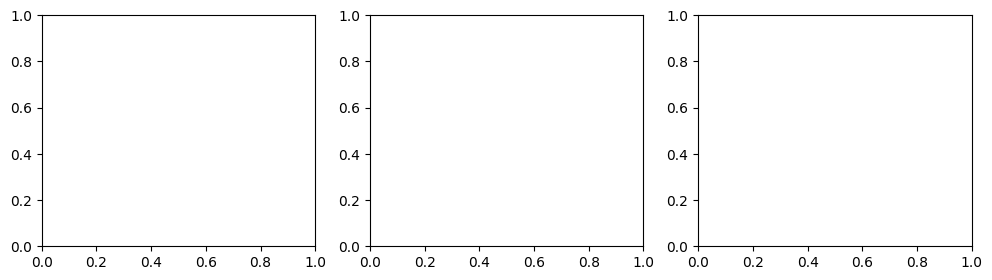

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

bs_labels = BS_ORDER
x = np.arange(len(bs_labels))
w = 0.35

# Bandwidth and IOPS
for ax, (col, ylabel, title) in zip(axes[:2], [
    ("bw_GiBs", "GiB/s", "Bandwidth"),
    ("iops",   "IOPS", "IOPS"),
]):
    for i, backend in enumerate(["daos", "nvmeof"]):
        vals = [df[(df.backend == backend) & (df.block_size == bs)][col].values[0]
                for bs in bs_labels]
        bars = ax.bar(x + (i - 0.5) * w, vals, w,
                      label=LABELS[backend], color=COLORS[backend], alpha=0.85)
        for bar, v in zip(bars, vals):
            label = f"{v:.2f}" if col == "bw_GiBs" else f"{v/1e3:.0f}K" if v >= 1000 else f"{v:.0f}"
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                    label, ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(bs_labels)
    ax.set_xlabel("Block size")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

# CPU usage (stacked usr + sys)
ax = axes[2]
w_cpu = 0.18
for i, backend in enumerate(["daos", "nvmeof"]):
    usr_vals = [df[(df.backend == backend) & (df.block_size == bs)]["usr_cpu"].values[0]
                for bs in bs_labels]
    sys_vals = [df[(df.backend == backend) & (df.block_size == bs)]["sys_cpu"].values[0]
                for bs in bs_labels]
    xi = x + (i - 0.5) * (w_cpu + 0.02)
    ax.bar(xi, usr_vals, w_cpu, label=f"{LABELS[backend]} — user",
           color=COLORS[backend], alpha=0.85)
    ax.bar(xi, sys_vals, w_cpu, bottom=usr_vals,
           label=f"{LABELS[backend]} — sys",
           color=COLORS[backend], alpha=0.4, hatch="///", edgecolor="white")
    for u, s, xi_ in zip(usr_vals, sys_vals, xi):
        ax.text(xi_, u + s + 0.8, f"{u+s:.0f}%",
                ha="center", va="bottom", fontsize=7.5)
ax.set_xticks(x)
ax.set_xticklabels(bs_labels)
ax.set_xlabel("Block size")
ax.set_ylabel("CPU usage (%)")
ax.set_title("CPU Usage — user (solid) + sys (hatched)")
ax.legend(ncol=1, fontsize=7.5, loc="best")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_ylim(0, 120)

# plt.suptitle("Sequential Read — DAOS (dfs) vs NVMe-oF (libaio), nj=1, iodepth=32", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fio_cmp_bw_iops_cpu.pdf", dpi=150, bbox_inches="tight")
plt.show()


## Latency Percentiles

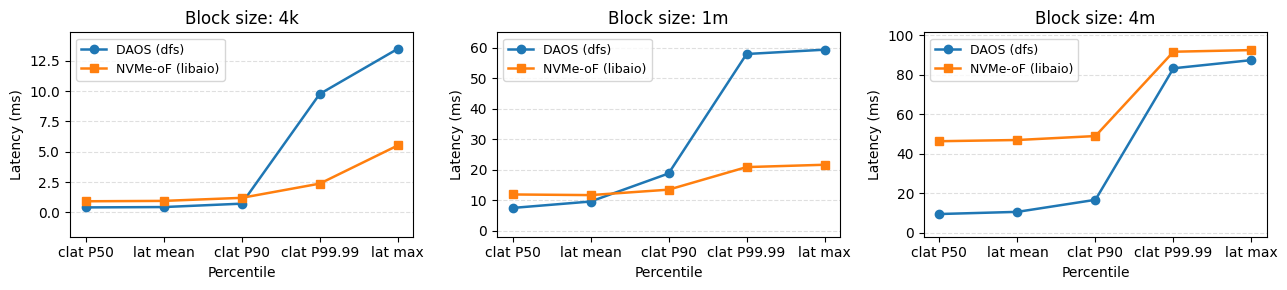

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=False)

pct_cols   = ["clat_p50_ms", "lat_mean_ms", "clat_p90_ms", "clat_p99_99_ms", "lat_max_ms"]
pct_labels = [ "clat P50", "lat mean", "clat P90", "clat P99.99", "lat max"]
markers    = {"daos": "o", "nvmeof": "s"}

for ax, bs in zip(axes, BS_ORDER):
    sub = df[df.block_size == bs]
    for backend in ["daos", "nvmeof"]:
        row = sub[sub.backend == backend].iloc[0]
        vals = [row[c] for c in pct_cols]
        ax.plot(pct_labels, vals,
                marker=markers[backend], label=LABELS[backend],
                color=COLORS[backend], linewidth=1.8, markersize=6)

    ax.set_title(f"Block size: {bs}")
    ax.set_xlabel("Percentile")
    ax.set_ylabel("Latency (ms)")
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_ylim(bottom=-2, top=ax.get_ylim()[1] * 1.05)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fio_cmp_latency.pdf", dpi=150, bbox_inches="tight")
plt.show()


## Key Findings

**Setup:** fio sequential read, numjobs=1, iodepth=32. DAOS uses the `dfs` userspace ioengine; NVMe-oF uses kernel `libaio`.

---

### 1. DAOS outperforms NVMe-oF on bandwidth at all block sizes
- 4K: 0.27 GiB/s vs 0.13 GiB/s — **2.1×**
- 1M: 3.26 GiB/s vs 2.68 GiB/s — **1.2×**
- 4M: 11.56 GiB/s vs 2.66 GiB/s — **4.4×**

The advantage widens dramatically at 4M. NVMe-oF submission latency spikes to 478 µs at 4M (vs 51 µs for DAOS), indicating that the kernel I/O stack imposes significant per-IO overhead at large transfer sizes.

### 2. DAOS mean latency is lower, but tail latency diverges at 1M
- 4K and 4M: DAOS wins on all percentiles.
- 1M: DAOS is faster on average (9.5 ms vs 11.7 ms) but **NVMe-oF has substantially better tail latency** — p99: 15.8 ms vs 32.9 ms; p99.9: 19.0 ms vs 46.9 ms.
  DAOS stddev at 1M is 6.8 ms vs 1.65 ms for NVMe-oF, suggesting occasional scheduling or network jitter in the DAOS client path.

### 3. DAOS is entirely user-space CPU bound; NVMe-oF is kernel-dominated
| Block size | DAOS usr+sys | NVMe-oF usr+sys |
|-----------|-------------|----------------|
| 4K        | **99.5%** (99.3 usr + 0.3 sys) | 25.6% (4.7 usr + 20.8 sys) |
| 1M        | 64.3% (57.1 usr + 7.2 sys)     | 24.6% (1.0 usr + 23.6 sys) |
| 4M        | 60.4% (39.5 usr + 20.9 sys)    | 32.8% (0.2 usr + 32.5 sys) |

DAOS trades CPU cycles for throughput via its userspace RDMA path. At 4K, it nearly saturates one core to deliver 2× the bandwidth — viable if spare cores are available, costly if CPU-constrained.

## pvsync2 NVMe-oF Repeat-Run Consistency Check

10 repeated runs of `pvsync2` ioengine on NVMe-oF (seq read, bs=4M, nj=1, iodepth=32) to assess run-to-run variance.

In [4]:
import statistics

pvsync2_files = sorted(RESULTS_DIR.glob("pvsync2_nvmeof_*.json"))
records = []
for fpath in pvsync2_files:
    with open(fpath) as f:
        d = json.load(f)
    r = d["jobs"][0]["read"]
    records.append(dict(
        file       = fpath.name,
        bw_GiBs    = r["bw_bytes"] / (1024**3),
        iops       = r["iops"],
        lat_mean_ms= r["lat_ns"]["mean"] / 1e6,
        clat_p50_ms= r["clat_ns"]["percentile"]["50.000000"] / 1e6,
    ))

pv_df = pd.DataFrame(records)

# Summary stats
summary = {}
for col in ["bw_GiBs", "iops", "lat_mean_ms", "clat_p50_ms"]:
    vals = pv_df[col].tolist()
    mu = statistics.mean(vals)
    sd = statistics.stdev(vals)
    summary[col] = dict(min=min(vals), max=max(vals), mean=mu, std=sd, cv_pct=sd/mu*100)

summary_df = pd.DataFrame(summary).T.round(3)
summary_df.index.name = "metric"
print("Per-run results:")
print(pv_df.to_string(index=False))
print("\nAggregate stats (n=10):")
print(summary_df)

Per-run results:
                                                  file  bw_GiBs       iops  lat_mean_ms  clat_p50_ms
pvsync2_nvmeof_seq_read_bs4m_nj1_iod32_1781810430.json 0.926836 237.269983     4.213711     4.014080
pvsync2_nvmeof_seq_read_bs4m_nj1_iod32_1781810467.json 0.819096 209.688522     4.247546     4.046848
pvsync2_nvmeof_seq_read_bs4m_nj1_iod32_1781810507.json 0.832879 213.217067     4.165243     3.948544
pvsync2_nvmeof_seq_read_bs4m_nj1_iod32_1781810546.json 0.833755 213.441158     4.163269     3.981312
pvsync2_nvmeof_seq_read_bs4m_nj1_iod32_1781810586.json 0.833682 213.422466     4.159203     3.948544
pvsync2_nvmeof_seq_read_bs4m_nj1_iod32_1781810626.json 0.837176 214.317123     4.135810     3.948544
pvsync2_nvmeof_seq_read_bs4m_nj1_iod32_1781810665.json 0.830916 212.714577     4.171020     3.981312
pvsync2_nvmeof_seq_read_bs4m_nj1_iod32_1781810705.json 0.843706 215.988655     4.108622     3.915776
pvsync2_nvmeof_seq_read_bs4m_nj1_iod32_1781810744.json 0.832685 213.167332

### Consistency findings

| Metric | Min | Max | Mean | Std | CV |
|---|---|---|---|---|---|
| BW (GiB/s) | 0.819 | 0.926 | 0.840 | 0.031 | 3.7% |
| IOPS | 209.7 | 237.3 | 215.3 | 7.9 | 3.7% |
| lat\_mean (ms) | 4.11 | 4.25 | 4.18 | 0.04 | 1.0% |
| clat\_p50 (ms) | 3.92 | 4.05 | 3.97 | 0.04 | 1.0% |

**Run 1 is an outlier:** the first run (`1781810430`) shows ~10% higher BW/IOPS (0.926 GiB/s, 237 IOPS) compared to the 9 subsequent runs (0.819–0.843 GiB/s). This is consistent with a warm-kernel-buffer or page-cache effect on the first run.

**Runs 2–10 are consistent:** CV ≈ 1–2% on bandwidth and <1% on latency — normal fio measurement noise. These runs are suitable as a stable baseline for pvsync2 on NVMe-oF.